In [1]:
import pandas as pd

df = pd.read_csv("youtube_labeled_dataset.csv")

In [3]:
print(df.isnull().sum())

df = df.dropna(subset=["clean_text", "sentiment"])

comment_id             0
comment_text           0
likes_on_comment       0
reply_count            0
published_at           0
video_id               0
views                  0
likes                  0
comment_count          0
channel_subscribers    0
clean_text             0
sentiment              0
dtype: int64


In [5]:
df = df.drop_duplicates(subset="clean_text")

In [7]:
df["clean_text"] = df["clean_text"].str.strip()

df = df[df["clean_text"] != ""]
df = df[df["clean_text"].str.len() > 5]

**STEP 5 — Remove noise (VERY IMPORTANT)**

**Remove:**

**numbers-only comments
code-like comments**

In [11]:
df = df[~df["clean_text"].str.match(r'^\d+$')]  # remove numbers only
df = df[~df["clean_text"].str.contains("print|input|def|class")]  # remove code

In [13]:
label_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

df["label"] = df["sentiment"].map(label_map)

In [15]:
import numpy as np

df["usefulness_score"] = (
    np.log1p(df["likes_on_comment"]) +
    np.log1p(df["reply_count"] + 1)
)

df["engagement_score"] = df["likes"] / (df["views"] + 1)

df["final_score"] = (
    0.6 * df["usefulness_score"] +
    0.4 * df["engagement_score"]
)

In [17]:
df_final = df[[
    "clean_text",
    "label",
    "usefulness_score",
    "engagement_score",
    "final_score"
]]

In [19]:
df_final.to_csv("final_ml_dataset.csv", index=False)

print("✅ Preprocessing completed!")
print("Final rows:", len(df_final))

✅ Preprocessing completed!
Final rows: 6820


In [21]:
print(df.isnull().sum())

comment_id             0
comment_text           0
likes_on_comment       0
reply_count            0
published_at           0
video_id               0
views                  0
likes                  0
comment_count          0
channel_subscribers    0
clean_text             0
sentiment              0
label                  0
usefulness_score       0
engagement_score       0
final_score            0
dtype: int64


**EDA**

1. SENTIMENT DISTRIBUTION

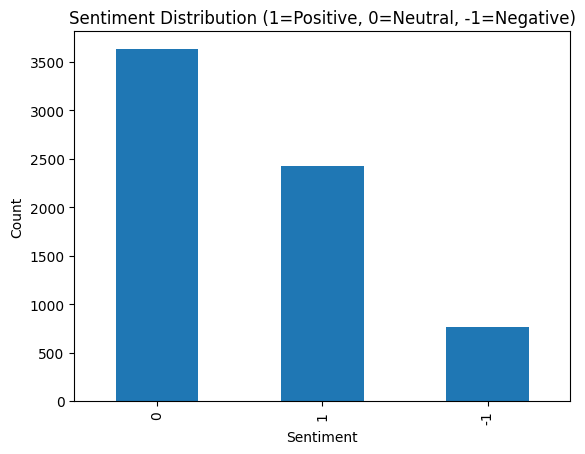

In [25]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution (1=Positive, 0=Neutral, -1=Negative)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

**2. COMMENT LENGTH ANALYSIS**

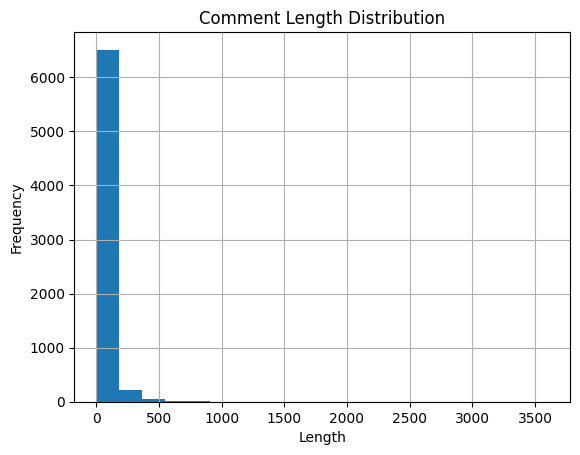

In [30]:
df["length"] = df["clean_text"].apply(len)

df["length"].hist(bins=20)
plt.title("Comment Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

**3. LENGTH vs SENTIMENT**

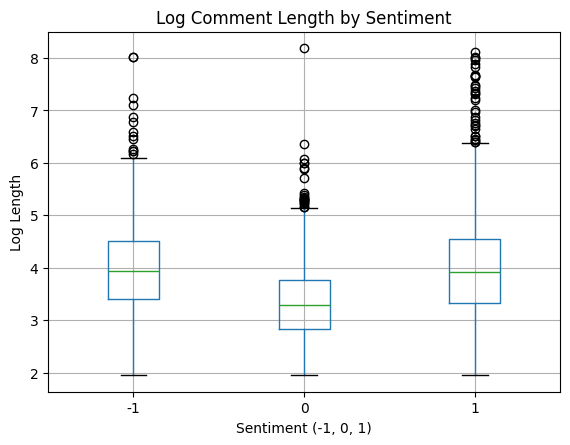

In [35]:
import numpy as np

df["log_length"] = np.log1p(df["length"])
df.boxplot(column="log_length", by="label")

import matplotlib.pyplot as plt
plt.title("Log Comment Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment (-1, 0, 1)")
plt.ylabel("Log Length")
plt.show()

**4. USEFULNESS DISTRIBUTION**

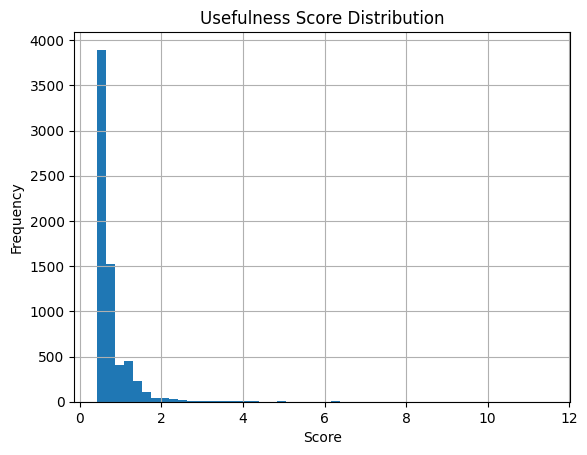

In [38]:
df["final_score"].hist(bins=50)
plt.title("Usefulness Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

**SENTIMENT PERCENTAGE**

In [41]:
sentiment_percent = df["label"].value_counts(normalize=True) * 100
print(sentiment_percent)

label
 0    53.255132
 1    35.571848
-1    11.173021
Name: proportion, dtype: float64


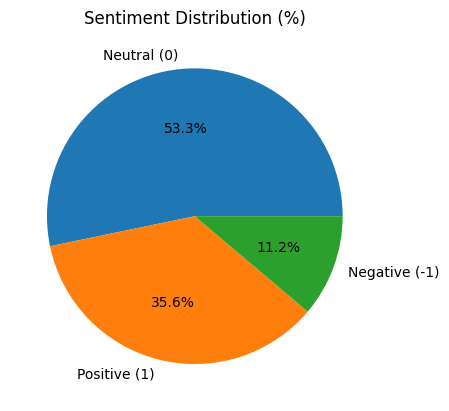

In [43]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Neutral (0)", "Positive (1)", "Negative (-1)"]
)

plt.title("Sentiment Distribution (%)")
plt.ylabel("")
plt.show()

In [45]:
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

In [47]:
df.sample(5)

,comment_id,comment_text,likes_on_comment,reply_count,published_at,video_id,views,likes,comment_count,channel_subscribers,clean_text,sentiment,label,usefulness_score,engagement_score,final_score,length,log_length,word_count
4744,Ugzqye6N_1dB-KXgv3h4AaABAg,wen lambo?,4,0,2026-03-19T19:26:43Z,9bZkp7q19f0,5883139747,31590515,5453479,20300000,wen lambo,neutral,0,2.302585,0.005370,1.383699,9,2.302585,2
777,UgxxvuDxaxAu9z0Gvel4AaABAg,Is this typo of things on YouTube comparable w...,1,1,2025-10-12T01:52:51Z,aircAruvnKk,22573830,533329,8810,8190000,is this typo of things on youtube comparable w...,neutral,0,1.791759,0.023626,1.084506,65,4.189655,11
5739,UgxtjnzONPv16E4kH5N4AaABAg,Are you done starving me,0,0,2026-03-18T20:41:05Z,3fumBcKC6RE,228321644,1094582,80607,4670000,are you done starving me,negative,-1,0.693147,0.004794,0.417806,24,3.218876,5
1377,UgxXj8Sz9eQ7pGdG8Tt4AaABAg,I'm at 36:14,0,0,2025-12-11T23:10:28Z,8hly31xKli0,5741176,149808,1966,11500000,im at 3614,neutral,0,0.693147,0.026094,0.426326,10,2.397895,3
663,UgyBPaY2N20kdBOhXop4AaABAg,Is Lisa real or AI?,0,0,2025-12-13T12:20:34Z,aircAruvnKk,22573830,533329,8810,8190000,is lisa real or ai,neutral,0,0.693147,0.023626,0.425339,18,2.944439,5


In [49]:
df['word_count'].describe()

count    6820.00000
mean       11.63783
std        26.99615
min         1.00000
25%         4.00000
50%         6.00000
75%        12.00000
max       668.00000
Name: word_count, dtype: float64

In [53]:
pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # 🔥 THIS IS THE IMPORTANT ONE
nltk.download('stopwords')
nltk.download('wordnet')
   

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     

True

In [60]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords + non-alphabetic words
    filtered = [
        word for word in tokens 
        if word.lower() not in stop_words and word.isalpha()
    ]
    
    return " ".join(filtered)

df["processed_text"] = df["clean_text"].apply(preprocess_text)

In [63]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized)

df["processed_text"] = df["processed_text"].apply(lemmatize_text)

In [65]:
df_final = df[[
    "processed_text",
    "label",
    "word_count",
    "usefulness_score",
    "engagement_score",
    "final_score"
]]

In [69]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def count_stopwords(text):
    words = text.split()
    return sum(1 for word in words if word in stop_words)

df["stopword_count"] = df["clean_text"].apply(count_stopwords)

In [71]:
df["stopword_ratio"] = df["stopword_count"] / (df["word_count"] + 1)

In [75]:

from collections import Counter

all_words = []

for text in df["processed_text"]:
    words = text.split()
    all_words.extend(words)

In [77]:
word_freq = Counter(all_words)

top_25 = word_freq.most_common(25)

In [79]:
words = [w[0] for w in top_25]
counts = [w[1] for w in top_25]

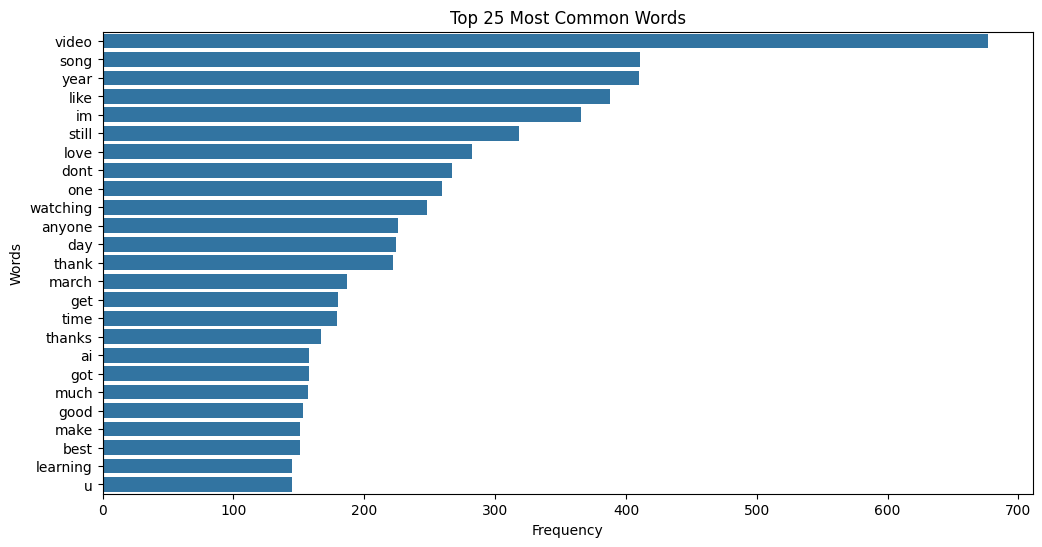

In [83]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=words)

plt.title("Top 25 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129327 (\N{SHOCKED FACE WITH EXPLODING HEAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


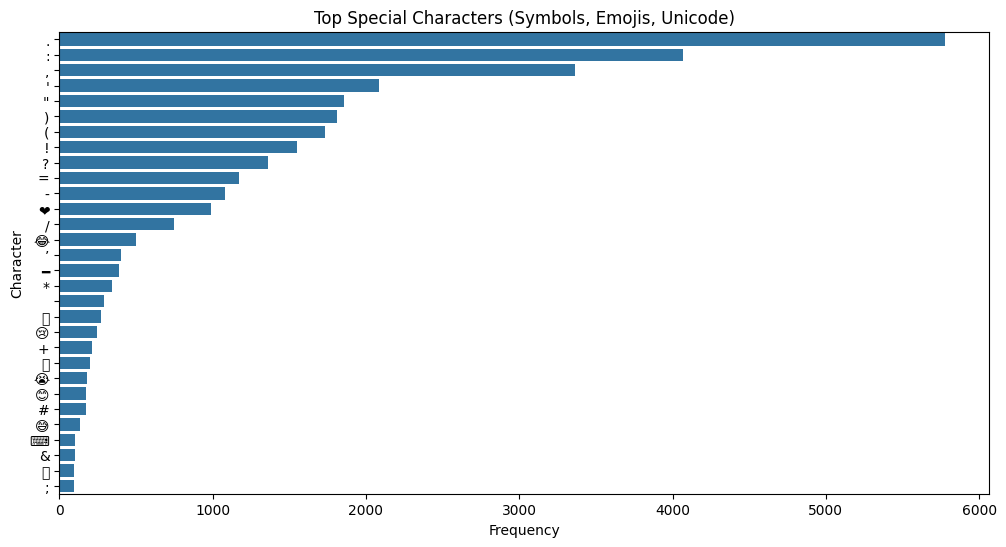

In [85]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("youtube_labeled_dataset.csv")

# 🔹 Step 1: Extract ALL non-alphanumeric characters (includes emojis, Chinese, symbols)
def extract_special_chars(text):
    text = str(text)
    return re.findall(r'[^\w\s]', text, flags=re.UNICODE)

# Collect all special characters
all_special_chars = []

for text in df["comment_text"]:
    all_special_chars.extend(extract_special_chars(text))

# 🔹 Step 2: Count frequency
char_freq = Counter(all_special_chars)

# 🔹 Step 3: Get top 30 characters
top_chars = char_freq.most_common(30)

chars = [c[0] for c in top_chars]
counts = [c[1] for c in top_chars]

# 🔹 Step 4: Plot
plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=chars)

plt.title("Top Special Characters (Symbols, Emojis, Unicode)")
plt.xlabel("Frequency")
plt.ylabel("Character")

plt.show()

In [67]:
df_final.to_csv("final_processed_dataset.csv", index=False)

In [89]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    tokens = word_tokenize(str(text))
    filtered = [w for w in tokens if w.lower() not in stop_words and w.isalpha()]
    return " ".join(filtered)

df["processed_text"] = df["clean_text"].apply(preprocess_text)

In [91]:
X = vectorizer.fit_transform(df["clean_text"])

In [93]:
print(df.columns)

Index(['comment_id', 'comment_text', 'likes_on_comment', 'reply_count',
       'published_at', 'video_id', 'views', 'likes', 'comment_count',
       'channel_subscribers', 'clean_text', 'sentiment', 'processed_text'],
      dtype='object')


In [95]:
from sklearn.feature_extraction.text import CountVectorizer

# Use processed_text if exists, else fallback
text_column = "processed_text" if "processed_text" in df.columns else "clean_text"

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=25)

X = vectorizer.fit_transform(df[text_column])

bigrams = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

import pandas as pd

bigram_df = pd.DataFrame({
    "bigram": bigrams,
    "count": counts
}).sort_values(by="count", ascending=False)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31160\2948227962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="bigram", data=bigram_df, palette="viridis")


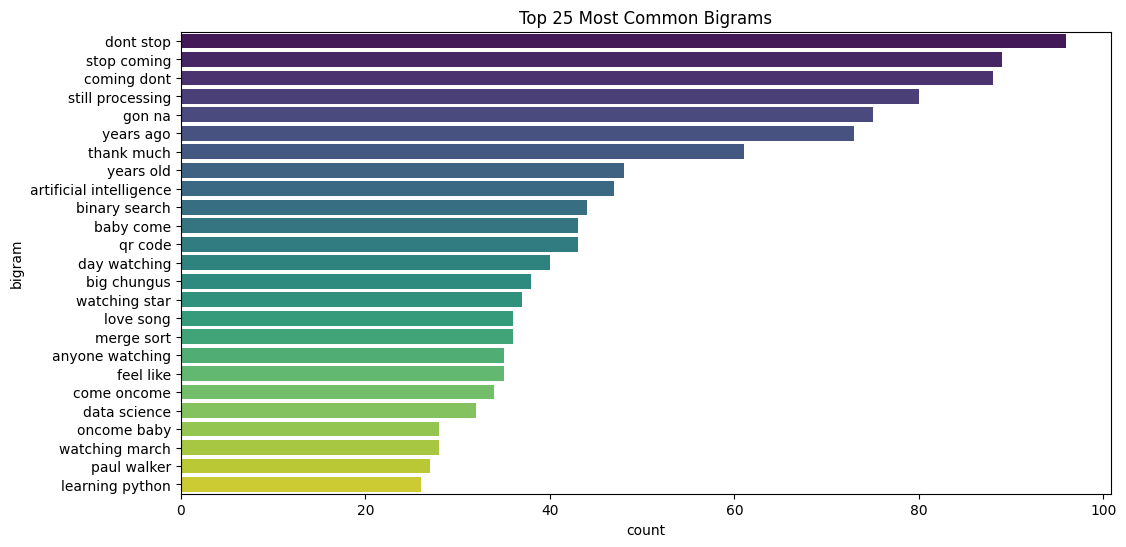

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x="count", y="bigram", data=bigram_df, palette="viridis")

plt.title("Top 25 Most Common Bigrams")
plt.show()

In [103]:
jupyter nbconvert --to html "EDA AND PREPROCESSING.ipynb"

SyntaxError: invalid syntax (62583500.py, line 1)

In [105]:
pip install nbconvert


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
!jupyter nbconvert --to html "EDA AND PREPROCESSING.ipynb"

[NbConvertApp] Converting notebook EDA AND PREPROCESSING.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 610160 bytes to EDA AND PREPROCESSING.html


In [111]:
!jupyter nbconvert --to html --no-input "EDA AND PREPROCESSING.ipynb"


[NbConvertApp] Converting notebook EDA AND PREPROCESSING.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 559013 bytes to EDA AND PREPROCESSING.html


In [113]:
import os
print(os.getcwd())

C:\Users\LENOVO\ML PROJECT
